# Feature Importance & Interpretability

Permutation importance (model-agnostic, on validation) for the final model, plus native coefficients/importances. SHAP optional — uncomment the last cell if `shap` is installed.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from src.preprocessing import prepare_data
from src.prediction import load_final
from src import config

In [2]:
data = prepare_data()
model, pre, feature_names = load_final()   # run final_selection.ipynb first
print('loaded final model')

loaded final model


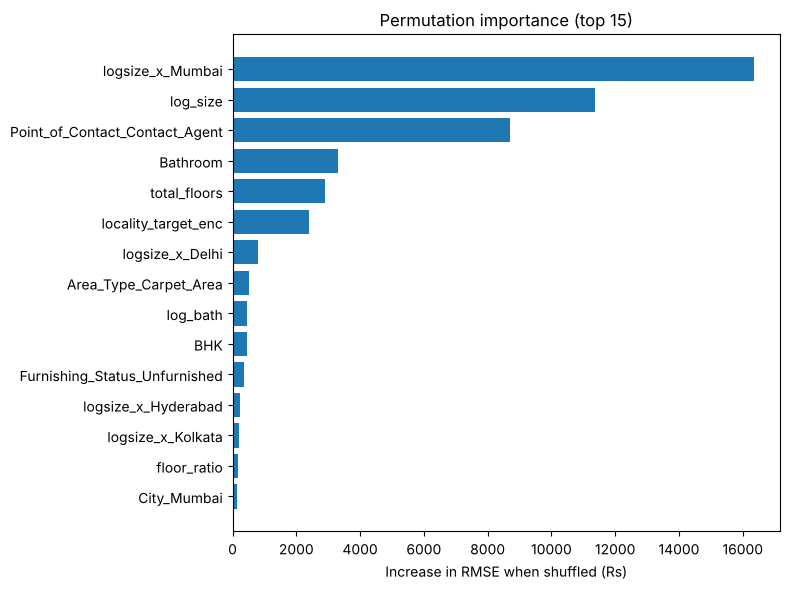

logsize_x_Mumbai                  16349.987109
log_size                          11361.796484
Point_of_Contact_Contact_Agent     8706.539062
Bathroom                           3298.262500
total_floors                       2911.806641
locality_target_enc                2406.805469
logsize_x_Delhi                     788.252344
Area_Type_Carpet_Area               531.728906
log_bath                            469.580078
BHK                                 449.314062
Furnishing_Status_Unfurnished       373.248828
logsize_x_Hyderabad                 242.474609
logsize_x_Kolkata                   218.860156
floor_ratio                         160.091016
City_Mumbai                         146.623828
dtype: float64

In [3]:
r = permutation_importance(model, data['X_val'], data['y_val'], n_repeats=10,
                            random_state=config.RANDOM_STATE, scoring='neg_root_mean_squared_error')
imp = pd.Series(r.importances_mean, index=feature_names).sort_values(ascending=False)
imp.to_csv(config.REPORTS/'feature_importance_permutation.csv')
top = imp.head(15)[::-1]
plt.figure(figsize=(8,6)); plt.barh(top.index, top.values)
plt.xlabel('Increase in RMSE when shuffled (Rs)'); plt.title('Permutation importance (top 15)')
config.VIZ_DIR.mkdir(parents=True, exist_ok=True)
plt.tight_layout(); plt.savefig(config.VIZ_DIR/'feature_importance.png', dpi=110); plt.show()
imp.head(15)

In [4]:
# Optional SHAP (uncomment if installed: pip install shap)
# import shap
# inner = model.regressor_.named_steps['model'] if hasattr(model,'regressor_') else model.named_steps['model']
# explainer = shap.Explainer(inner, data['X_train'])
# sv = explainer(data['X_val']); shap.plots.beeswarm(sv, max_display=15)